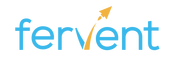
# Estimating Portfolio Risk (Multiple Assets) - Applied
In this walkthrough, you'll learn how to the risk of a multi asset portfolio.

### The risk of a $k$ asset portfolio is calculated as...
$$\sigma_p^2 = var(\mathbf{\Omega'R})$$  
$$\sigma_p^2 = \mathbf{\Omega'\sum\Omega}$$  
$$\sigma_p = \sqrt{\sigma_p^2}$$

Where:  
$\sigma_p^2 = $ The variance of the portfolio  
$\sigma_p = $ The standard deviation (risk) of the portfolio  
$\mathbf{\Omega} = $ Vector of 'weights'  
$\mathbf{\sum} = $ Variance Covariance (VCV) Matrix  
$\mathbf{R} =$ Matrix of Returns


In [1]:
# Import package dependencies
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/10stocks_price.csv')

In [3]:
df.head()

,date_gsheets,AAPL,KO,NFLX,BRK.B,DIS,IBM,VZ,WMT,GE,TSLA
0,01/03/2012 16:00,58.75,35.07,10.32,77.68,38.31,186.30,39.73,60.33,18.36,28.08
1,01/04/2012 16:00,59.06,34.85,11.49,76.80,38.85,185.54,39.21,59.71,18.56,27.71
2,01/05/2012 16:00,59.72,34.69,11.33,76.93,39.50,184.66,38.94,59.42,18.55,27.12
3,01/06/2012 16:00,60.34,34.47,12.33,76.39,39.91,182.54,38.33,59.00,18.65,26.91
4,01/09/2012 16:00,60.25,34.47,14.03,76.29,39.75,181.59,38.37,59.18,18.86,27.25


In [6]:
type(df['date_gsheets'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [5]:
# Convert string format dates to pandas datetime objects
# This helps us explore the time series dataset (e.g., determining start and end of the sample)
df['date_gsheets'] = pd.to_datetime(df['date_gsheets'])

In [7]:
df['date_gsheets'].describe()

count                    1509
unique                   1509
top       2012-01-03 16:00:00
freq                        1
first     2012-01-03 16:00:00
last      2017-12-29 16:00:00
Name: date_gsheets, dtype: object

In [8]:
# Exploring the data
df.describe()

,AAPL,KO,NFLX,BRK.B,DIS,IBM,VZ,WMT,GE,TSLA
count,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000
mean,102.874380,41.119881,77.348801,130.578032,84.278529,172.739881,47.687641,73.481365,25.564983,185.623453
std,28.856614,2.915722,52.093716,29.738410,23.340639,21.860902,3.686156,7.579578,3.725205,97.668462
min,55.790000,33.490000,7.690000,76.290000,38.310000,117.850000,36.800000,56.420000,17.360000,22.790000
25%,78.440000,38.900000,34.220000,112.700000,64.020000,154.000000,45.560000,69.120000,23.190000,117.820000
50%,99.520000,41.170000,64.360000,134.140000,92.030000,173.480000,48.120000,73.780000,25.790000,207.830000
75%,119.250000,43.000000,110.100000,146.690000,104.030000,191.950000,50.030000,77.490000,28.630000,247.740000
max,176.420000,47.430000,202.680000,199.560000,121.690000,215.800000,56.530000,99.620000,32.930000,385.000000


In [9]:
# Exploring the datatypes, checking for NaNs
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1509 entries, 0 to 1508
Data columns (total 11 columns):
date_gsheets    1509 non-null datetime64[ns]
AAPL            1509 non-null float64
KO              1509 non-null float64
NFLX            1509 non-null float64
BRK.B           1509 non-null float64
DIS             1509 non-null float64
IBM             1509 non-null float64
VZ              1509 non-null float64
WMT             1509 non-null float64
GE              1509 non-null float64
TSLA            1509 non-null float64
dtypes: datetime64[ns](1), float64(10)
memory usage: 129.8 KB


In [10]:
# Set the date column as the index to apply formulas to the dataframe as a whole
df.set_index('date_gsheets', inplace=True)

In [11]:
df.head()

,AAPL,KO,NFLX,BRK.B,DIS,IBM,VZ,WMT,GE,TSLA
date_gsheets,,,,,,,,,,
2012-01-03 16:00:00,58.75,35.07,10.32,77.68,38.31,186.30,39.73,60.33,18.36,28.08
2012-01-04 16:00:00,59.06,34.85,11.49,76.80,38.85,185.54,39.21,59.71,18.56,27.71
2012-01-05 16:00:00,59.72,34.69,11.33,76.93,39.50,184.66,38.94,59.42,18.55,27.12
2012-01-06 16:00:00,60.34,34.47,12.33,76.39,39.91,182.54,38.33,59.00,18.65,26.91
2012-01-09 16:00:00,60.25,34.47,14.03,76.29,39.75,181.59,38.37,59.18,18.86,27.25


In [12]:
# Calculate returns for each stock, at each time
returns_df = df.pct_change(1)

In [14]:
# Create a vector of equal weights (\omega_1 = \omega_1 = ... = \omega_10)
num_stocks = 10
weights = [1 / num_stocks] * num_stocks

In [15]:
weights

[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]

In [16]:
# Calculate the variance covariance matrix
vcv_matrix = returns_df.cov()

In [17]:
vcv_matrix

,AAPL,KO,NFLX,BRK.B,DIS,IBM,VZ,WMT,GE,TSLA
AAPL,0.000246,0.000028,0.000059,0.000044,0.000048,0.000048,0.000027,0.000029,0.000047,0.000094
KO,0.000028,0.000075,0.000026,0.000037,0.000037,0.000032,0.000033,0.000029,0.000035,0.000038
NFLX,0.000059,0.000026,0.001063,0.000054,0.000057,0.000046,0.000015,0.000035,0.000060,0.000230
BRK.B,0.000044,0.000037,0.000054,0.000080,0.000055,0.000050,0.000038,0.000032,0.000057,0.000060
DIS,0.000048,0.000037,0.000057,0.000055,0.000132,0.000045,0.000039,0.000034,0.000058,0.000080
IBM,0.000048,0.000032,0.000046,0.000050,0.000045,0.000132,0.000035,0.000028,0.000057,0.000065
VZ,0.000027,0.000033,0.000015,0.000038,0.000039,0.000035,0.000103,0.000032,0.000044,0.000034
WMT,0.000029,0.000029,0.000035,0.000032,0.000034,0.000028,0.000032,0.000115,0.000030,0.000036
GE,0.000047,0.000035,0.000060,0.000057,0.000058,0.000057,0.000044,0.000030,0.000136,0.000066
TSLA,0.000094,0.000038,0.000230,0.000060,0.000080,0.000065,0.000034,0.000036,0.000066,0.000931


In [19]:
# Calculate the variance of the 10 asset portfoio
var_p = np.dot(np.transpose(weights), np.dot(vcv_matrix, weights))

In [20]:
var_p

7.332673907420124e-05

In [21]:
# Calculate the total risk (standard deviation) of the 10 asset portfolio
sd_p = np.sqrt(var_p)

In [22]:
sd_p

0.008563103355338018

In [23]:
# Calculate the Annualised Standard Deviation of the 10 asset portfolio
sd_p_annual = sd_p * np.sqrt(250)

In [24]:
sd_p_annual

0.13539455221149152

In [25]:
# Compare the Portfolio Risk with the individual risks of each security
individual_risks = np.std(returns_df) * np.sqrt(250)

In [26]:
individual_risks

AAPL     0.248003
KO       0.137257
NFLX     0.515302
BRK.B    0.141030
DIS      0.181313
IBM      0.181705
VZ       0.160220
WMT      0.169281
GE       0.184478
TSLA     0.482230
dtype: float64